In [1]:
# Librerías de serialización y manejo de datos
import joblib as jb
import pandas as pd
import numpy as np

# Librerías de visualización
import matplotlib.pyplot as plt
import seaborn as sns

# Herramientas de sklearn para modelado
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, f1_score, fbeta_score, cohen_kappa_score, classification_report, make_scorer, mean_absolute_error

# Estadística (correlación de Spearman)
import scipy.stats as stats

# Preprocesamiento e imputación
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Estimadores personalizados de sklearn
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.utils.validation import check_is_fitted

In [ ]:
# Carga del dataset principal desde Excel
df = pd.read_excel("Archivo_IS_MRI_actualizado.xlsx")
print(f"Datos cargados: {df.shape[0]} filas, {df.shape[1]} columnas")

Datos cargados: 256 filas, 186 columnas


In [3]:
# Selección de variables de entrada (X) y de la variable objetivo (y)
#     R_A: escala de rankin modificada al alta
#     VOL: volume de la lesión isquémica medido en la tomografía computarizada de control entre el 4º y 7º día
#     TOAST: etiología del ictus
#     shape_volume_ml: característica radiómica que representa el volumen de la lesión en ml
#     intensity_range: característica radiómica de intensidad
# La variable objetivo es R_3: escala mRS a los 3 meses (ordinal, 0-6)
X = df[[c for c in df.columns if c.startswith("R_A") or c.startswith("VOL") or
        c.startswith("TOAST") or c.startswith("shape_volume_ml") or c.startswith("intensity_range")]]
y = df["R_3"]

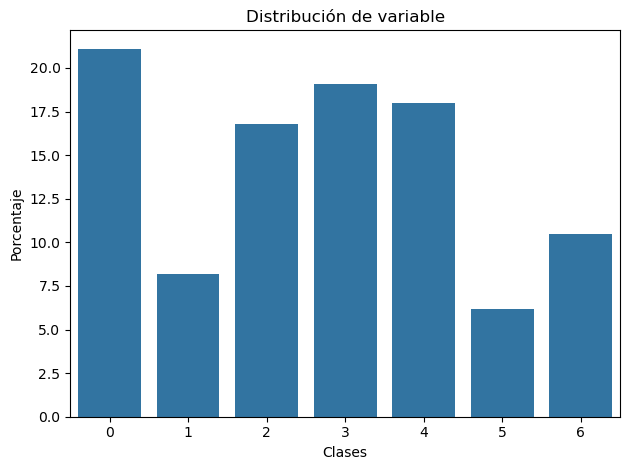

In [4]:
# Distribución de la variable objetivo (mRS a 3 meses)
conteo = df['R_3'].value_counts(normalize=True).mul(100).round(1)

sns.barplot(x=conteo.index, y=conteo.values)
plt.title('Distribución de variable')
plt.xlabel('Clases')
plt.ylabel('Porcentaje')
plt.tight_layout()
plt.show()

In [ ]:
# Clasificación de las variables de entrada según la estrategia de imputación establecida
# Los valores nulos se imputan de forma diferente según la naturaleza de cada variable:
#     cols_mediana_exp: variables continuas (radiómicas, volúmenes, NIH), imputación con la mediana (robusta frente a outliers)
#     cols_moda_exp: variables categóricas binarias o nominales, imputación con la moda (valor más frecuente)
#     cols_cero_exp: variables regionales/vasculares (vóxeles, porcentajes), si no hay un valor, la región no está afectada entonces se imputa por 0

cols_mediana_exp = [c for c in X.columns if c.startswith(('shape_', 'intensity_', 'texture_'))] + \
                   [c for c in ['ED', 'NIH_0', 'NIH_24', 'NIH_48', 'NIH_A', 'VOL',
                                'report_intracranial_volume', 'report_stroke_pct_of_ICV']
                    if c in X.columns]

cols_moda_exp = [c for c in ['SEX', 'TBC', 'ENO', 'AIT', 'IP', 'DWI_0', 'TH', 'TOAST', 'mRS_0']
                 if c in X.columns]

cols_cero_exp = [c for c in X.columns
                 if any(c.endswith(s) for s in ['_voxels', '_pct', '_affected',
                                                 '_pct_of_stroke', '_pct_of_ICV'])
                 and c not in cols_mediana_exp
                 and c not in cols_moda_exp]

# Divisón del conjunto de datos para obtener el conjunto de entrenamiento y el de prueba
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.15, random_state=42, stratify=y
)

# Validación cruzada estratificada (5 folds)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Scorer de MAE para GridSearchCV, se invierte el signo del MAE internamente con el objetivo de que en el GridSearchCV se minimice el MAE
mae_scorer = make_scorer(mean_absolute_error, greater_is_better=False)

# Espacio de búsqueda de hiperparámetros.
param_grid = {
    'clf__max_depth': [2, 3, 4, 5, 6, 8, 10, 12, 14, 16, 18, 20],
    'clf__min_samples_leaf': [2, 3, 5, 7, 9, 11, 13, 15, 17, 19]
}

In [ ]:
def refit_combinado(cv_results):
    '''
    Función de refit combinado que combina dos métricas de validación cruzada con pesos:
        puntuación = 0.7 * F1-macro + 0.3 * (MAE/6)
    Devuelve el índice de la configuración con la puntuación combinada más alta.
    '''
    f1 = np.array(cv_results['mean_test_f1_macro'])
    mae = np.array(cv_results['mean_test_mae'])
    mae_norm = mae/6
    return np.argmax(0.7*f1 + 0.3 * mae_norm)


class ClasificadorJerarquicoMRS(BaseEstimator, ClassifierMixin):
    """
    Clasificador jerárquico de la escala mRS (0-6) mediante árboles de decisión anidados.
    La predicción se realiza en tres niveles de árbol binario, siguiendo la estructura clínica de la escala de Rankin modificada:

        Nivel 1:  0-2 (independiente) vs 3-6 (dependiente)
        Nivel 2a: 0-1 vs 2 (solo pacientes clasificados como 0-2)
        Nivel 2b: 3-4 vs 5-6 (solo pacientes clasificados como 3-6)
        Nivel 3a: 0 vs 1 (solo pacientes clasificados como 0-1)
        Nivel 3b: 3 vs 4 (solo pacientes clasificados como 3-4)
        Nivel 3c: 5 vs 6 (solo pacientes clasificados como 5-6)
    
    Cada nivel tiene su propio GridSearchCV, entrenado sólo con el subconjunto de pacientes que llega a ese nodo de la jerarquía.
    """

    def __init__(self, crear_pipeline, param_grid, cv):
        self.crear_pipeline = crear_pipeline
        self.param_grid = param_grid
        self.cv = cv

    def _make_grid(self):
        '''
        Función que crea un GridSearchCV con una puntuación dual (F1-macro + MAE) y refit combinado.
        '''
        return GridSearchCV(
            self.crear_pipeline(),
            self.param_grid,
            cv=self.cv,
            scoring={
                'f1_macro': 'f1_macro',
                'mae': make_scorer(mean_absolute_error, greater_is_better=False)
            },
            refit=refit_combinado,
            return_train_score=True
        )

    def fit(self, X, y):
        '''
        Función que entrena los 6 clasificadores binarios de forma jerárquica.
        Cada nivel sólo ve el subconjunto de pacientes que le corresponde.
        '''
        y = np.array(y)
        X = np.array(X) if not hasattr(X, 'iloc') else X

        # Nivel 1: independiente (0-2) vs dependiente (3-6)
        # 0 = mRS 0-2 (independiente), 1 = mRS 3-6 (dependiente)
        y_n1 = (y >= 3).astype(int)
        self.gs_n1_ = self._make_grid()
        self.gs_n1_.fit(X, y_n1)

        # Nivel 2a: grado de independencia dentro de mRS 0-2
        # 0 = mRS 0-1 (muy buena recuperación), 1 = mRS 2 (leve dependencia)
        mask_indep = y <= 2
        self.gs_n2a_ = self._make_grid()
        self.gs_n2a_.fit(X[mask_indep], (y[mask_indep] >= 2).astype(int))

        # Nivel 2b: grado de dependencia dentro de mRS 3-6
        # 0 = mRS 3-4 (dependencia moderada), 1 = mRS 5-6 (dependencia grave / muerte)
        mask_dep = y >= 3
        self.gs_n2b_ = self._make_grid()
        self.gs_n2b_.fit(X[mask_dep], (y[mask_dep] >= 5).astype(int))

        # Nivel 3a: distinción fina dentro de mRS 0-1
        # 0 = mRS 0 (sin síntomas), 1 = mRS 1 (síntomas mínimos sin discapacidad)
        mask_01 = y <= 1
        self.gs_n3a_ = self._make_grid()
        self.gs_n3a_.fit(X[mask_01], (y[mask_01] >= 1).astype(int))

        # Nivel 3b: distinción fina dentro de mRS 3-4
        # 0 = mRS 3 (dependencia moderada), 1 = mRS 4 (dependencia moderadamente grave)
        mask_34 = (y >= 3) & (y <= 4)
        self.gs_n3b_ = self._make_grid()
        self.gs_n3b_.fit(X[mask_34], (y[mask_34] >= 4).astype(int))

        # Nivel 3c: distinción fina dentro de mRS 5-6
        # 0 = mRS 5 (dependencia grave), 1 = mRS 6 (muerte)
        mask_56 = y >= 5
        self.gs_n3c_ = self._make_grid()
        self.gs_n3c_.fit(X[mask_56], (y[mask_56] >= 6).astype(int))

        self.classes_ = np.arange(7)
        return self

    def predict(self, X):
        '''
        Función que genera predicciones recorriendo el árbol de decisión jerárquico.
        Cada muestra baja por el nivel correspondiente según la predicción del nivel superior.
        '''
        check_is_fitted(self)
        n = len(X)
        # Resultado = -1 (aún sin asignar)
        resultado = np.full(n, -1, dtype=int)

        # Nivel 1: clasificación independiente vs dependiente
        pred_n1 = self.gs_n1_.predict(X)  # 0 = indep, 1 = dep

        # Rama independiente (mRS 0-2)
        mask_indep = pred_n1 == 0
        if mask_indep.sum() > 0:
            X_indep = X[mask_indep] if not hasattr(X, 'iloc') else X.iloc[mask_indep]
            pred_n2a = self.gs_n2a_.predict(X_indep)  # 0 = mRS 0-1, 1 = mRS 2

            # Pacientes con mRS 2: asignación directa
            mask_2 = pred_n2a == 1
            idx_indep = np.where(mask_indep)[0]
            resultado[idx_indep[mask_2]] = 2

            # Pacientes con mRS 0-1: bajan al Nivel 3a
            mask_01 = pred_n2a == 0
            if mask_01.sum() > 0:
                X_01 = X_indep[mask_01] if not hasattr(X_indep, 'iloc') else X_indep.iloc[mask_01]
                pred_n3a = self.gs_n3a_.predict(X_01)  # 0 = mRS 0, 1 = mRS 1
                resultado[idx_indep[np.where(mask_01)[0][pred_n3a == 0]]] = 0
                resultado[idx_indep[np.where(mask_01)[0][pred_n3a == 1]]] = 1

        # Rama dependiente (mRS 3-6)
        mask_dep = pred_n1 == 1
        if mask_dep.sum() > 0:
            X_dep = X[mask_dep] if not hasattr(X, 'iloc') else X.iloc[mask_dep]
            pred_n2b = self.gs_n2b_.predict(X_dep)  # 0 = mRS 3-4, 1 = mRS 5-6

            idx_dep = np.where(mask_dep)[0]

            # Pacientes con mRS 3-4: bajan al Nivel 3b
            mask_34 = pred_n2b == 0
            if mask_34.sum() > 0:
                X_34 = X_dep[mask_34] if not hasattr(X_dep, 'iloc') else X_dep.iloc[mask_34]
                pred_n3b = self.gs_n3b_.predict(X_34)  # 0 = mRS 3, 1 = mRS 4
                resultado[idx_dep[np.where(mask_34)[0][pred_n3b == 0]]] = 3
                resultado[idx_dep[np.where(mask_34)[0][pred_n3b == 1]]] = 4

            # Pacientes con mRS 5-6: bajan al Nivel 3c
            mask_56 = pred_n2b == 1
            if mask_56.sum() > 0:
                X_56 = X_dep[mask_56] if not hasattr(X_dep, 'iloc') else X_dep.iloc[mask_56]
                pred_n3c = self.gs_n3c_.predict(X_56)  # 0 = mRS 5, 1 = mRS 6
                resultado[idx_dep[np.where(mask_56)[0][pred_n3c == 0]]] = 5
                resultado[idx_dep[np.where(mask_56)[0][pred_n3c == 1]]] = 6

        return resultado

    def print_cv_scores(self):
        '''
        Función que imprime el mejor F1-macro y MAE de validación cruzada de cada nivel.
        '''
        check_is_fitted(self)
        niveles = [
            ('Nivel 1 (0-2 vs 3-6)', self.gs_n1_),
            ('Nivel 2a (0-1 vs 2)', self.gs_n2a_),
            ('Nivel 2b (3-4 vs 5-6)', self.gs_n2b_),
            ('Nivel 3a (0 vs 1)', self.gs_n3a_),
            ('Nivel 3b (3 vs 4)', self.gs_n3b_),
            ('Nivel 3c (5 vs 6)', self.gs_n3c_),
        ]
        for nombre, gs in niveles:
            r = pd.DataFrame(gs.cv_results_)
            mejor = r.loc[r['mean_test_f1_macro'].idxmax()]
            print(f"{nombre}:")
            print(f"  F1 macro: {mejor['mean_test_f1_macro']:.3f} ± {mejor['std_test_f1_macro']:.3f}")
            print(f"  MAE:      {-mejor['mean_test_mae']:.3f} ± {mejor['std_test_mae']:.3f}")
            print(f"  Params:   {gs.best_params_}")

    def predict_proba(self, X):
        '''
        Función que calcula probabilidades de clase multiplicando las probabildiades condicionales a lo largo de
        los niveles jerárquicos. Las probabilidades se normalizan al final para que cada fila sume 1.
        '''
        check_is_fitted(self)
        n = len(X)
        proba = np.zeros((n, 7))

        # Nivel 1: P(independiente) y P(dependiente)
        p_n1 = self.gs_n1_.predict_proba(X)   # [:, 0]=P(indep), [:, 1]=P(dep)
        p_indep = p_n1[:, 0]
        p_dep = p_n1[:, 1]

        # Nivel 2a: P(mRS 0-1 | indep) y P(mRS 2 | indep)
        p_n2a = self.gs_n2a_.predict_proba(X)
        p_indep_01 = p_n2a[:, 0]
        p_indep_2 = p_n2a[:, 1]

        # Nivel 2b: P(mRS 3-4 | dep) y P(mRS 5-6 | dep)
        p_n2b = self.gs_n2b_.predict_proba(X)
        p_dep_34 = p_n2b[:, 0]
        p_dep_56 = p_n2b[:, 1]

        # Nivel 3a: P(mRS 0 | 0-1) y P(mRS 1 | 0-1)
        p_n3a = self.gs_n3a_.predict_proba(X)

        # Nivel 3b: P(mRS 3 | 3-4) y P(mRS 4 | 3-4)
        p_n3b = self.gs_n3b_.predict_proba(X)

        # Nivel 3c: P(mRS 5 | 5-6) y P(mRS 6 | 5-6)
        p_n3c = self.gs_n3c_.predict_proba(X)

        # Probabilidades finales: producto de probabilidades condicionales por nivel
        proba[:, 0] = p_indep * p_indep_01 * p_n3a[:, 0]
        proba[:, 1] = p_indep * p_indep_01 * p_n3a[:, 1]
        proba[:, 2] = p_indep * p_indep_2
        proba[:, 3] = p_dep * p_dep_34 * p_n3b[:, 0]
        proba[:, 4] = p_dep * p_dep_34 * p_n3b[:, 1]
        proba[:, 5] = p_dep * p_dep_56 * p_n3c[:, 0]
        proba[:, 6] = p_dep * p_dep_56 * p_n3c[:, 1]

        # Renormalización: cada fila debe sumar exactamente 1
        row_sums = proba.sum(axis=1, keepdims=True)
        proba = np.divide(proba, row_sums, where=row_sums > 0)

        return proba

def crear_pipeline_factory(cols_cero, cols_mediana, cols_moda):
    '''
    Devuelve una función sin argumentos que crea un Pipeline nuevo cada vez, porque ClasificadorJerarquicoMRS llama a
    crear_pipeline() una vez por nivel, y GridSearch necesita un estimador independiente para clonar en cada iteración.
    '''
    def crear_pipeline():
        return Pipeline([
            ('prep', ColumnTransformer(
                transformers=[
                    ('cero',SimpleImputer(strategy='constant', fill_value=0), cols_cero),
                    ('mediana', SimpleImputer(strategy='median'), cols_mediana),
                    ('moda', SimpleImputer(strategy='most_frequent'), cols_moda),
                ],
                remainder='passthrough'
            )),
            ('clf', DecisionTreeClassifier(class_weight='balanced', random_state=42))
        ])
    return crear_pipeline

def f1_macro_within1(y_true, y_pred):
    '''
    Función que devuelve la media de F1-macro que considera correcto cualquier error de +-1 punto mRS, por clase.
    Un error de +-1 punto en mRS raramente cambia la decisión terapéutica.
    '''
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    f_scores = []

    for k in np.unique(y_true):
        tp = np.sum((y_true == k) & (np.abs(y_pred - k) <= 1))
        fp = np.sum((y_true != k) & (np.abs(y_pred - y_true) > 1) & (y_pred == k))
        fn = np.sum((y_true == k) & (np.abs(y_pred - k) > 1))

        precision = tp / (tp + fp) if (tp + fp) > 0 else 0
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0
        denom = precision + recall

        f1 = 2 * precision * recall / denom if denom > 0 else 0
        f_scores.append(f1)

    return np.mean(f_scores)

In [ ]:
# Instanciación del clasificador jerárquico
clf_jerarquico = ClasificadorJerarquicoMRS(
    crear_pipeline=crear_pipeline_factory(cols_cero_exp, cols_mediana_exp, cols_moda_exp),
    param_grid=param_grid,
    cv=cv
)

# Entrenamiento 
clf_jerarquico.fit(X_train, y_train)

# Resumen de CV por nivel
clf_jerarquico.print_cv_scores()

# Predicciones sobre entrenamiento y prueba
y_pred_train = clf_jerarquico.predict(X_train)
y_pred_test = clf_jerarquico.predict(X_test)

# Métricas de evaluación globales
accuracy_train = accuracy_score(y_train, y_pred_train)
accuracy_test  = accuracy_score(y_test,  y_pred_test)
f1_macro_within1_train = f1_macro_within1(y_train, y_pred_train)
f1_macro_within1_test = f1_macro_within1(y_test, y_pred_test)
f1_macro_train = fbeta_score(y_train, y_pred_train, beta=1, average='macro', zero_division=0)
f1_macro_test = fbeta_score(y_test,  y_pred_test, beta=1, average='macro', zero_division=0)
kappa_train = cohen_kappa_score(y_train, y_pred_train)
kappa_test = cohen_kappa_score(y_test,  y_pred_test)

print(f"\n--- Métricas Train / Test ---")
print(f"Train Accuracy: {accuracy_train:.3f}     |  "
      f"Test Accuracy:  {accuracy_test:.3f}")

print(f"Train F1 macro within 1: {f1_macro_within1_train:.3f}  |  "
      f"Test F1 macro within 1:  {f1_macro_within1_test:.3f}")

print(f"Train F1 macro: {f1_macro_train:.3f}     |  "
      f"Test F1 macro:  {f1_macro_test:.3f}")

print(f"Train Kappa: {kappa_train:.3f}        |  "
      f"Test Kappa:  {kappa_test:.3f}")

# Informe detallado por clase (test)
print(f"\n--- Classification Report (Test) ---")
print(classification_report(y_test, y_pred_test))

Nivel 1 (0-2 vs 3-6):
  F1 macro: 0.786 ± 0.039
  MAE:      0.208 ± 0.039
  Params:   {'clf__max_depth': 3, 'clf__min_samples_leaf': 15}
Nivel 2a (0-1 vs 2):
  F1 macro: 0.733 ± 0.058
  MAE:      0.260 ± 0.058
  Params:   {'clf__max_depth': 3, 'clf__min_samples_leaf': 9}
Nivel 2b (3-4 vs 5-6):
  F1 macro: 0.767 ± 0.031
  MAE:      0.205 ± 0.031
  Params:   {'clf__max_depth': 2, 'clf__min_samples_leaf': 19}
Nivel 3a (0 vs 1):
  F1 macro: 0.635 ± 0.098
  MAE:      0.329 ± 0.081
  Params:   {'clf__max_depth': 4, 'clf__min_samples_leaf': 3}
Nivel 3b (3 vs 4):
  F1 macro: 0.685 ± 0.078
  MAE:      0.312 ± 0.079
  Params:   {'clf__max_depth': 6, 'clf__min_samples_leaf': 5}
Nivel 3c (5 vs 6):
  F1 macro: 0.892 ± 0.054
  MAE:      0.107 ± 0.054
  Params:   {'clf__max_depth': 2, 'clf__min_samples_leaf': 3}

--- Métricas Train / Test ---
Train Accuracy: 0.571     |  Test Accuracy:  0.615
Train F1 macro within 1: 0.803  |  Test F1 macro within 1:  0.922
Train F1 macro: 0.555     |  Test F1 macro:

In [ ]:
# Reconstrucción del orden de columnas tras ColumnTransformer para interpretar la importancia de cada característica del árbol
nombres_columnas = (
    cols_cero_exp +
    cols_mediana_exp +
    cols_moda_exp +
    [c for c in X.columns if c not in cols_cero_exp + cols_mediana_exp + cols_moda_exp]
)

def get_importancias_jerarquico(clf_jerarquico, nombre_nivel, gs):
    """
    Función que extrae las importancias de características del árbol óptimo seleccionado por GridSearchCV en un
    un nivel jerárquico dado. Las importancias basadas en impureza Gini indican qué variables contribuyeron más
    a las divisiones del árbol en ese nivel.
    Devuelve una Serie con las importancias > 0 ordenadas de mayor a menor.
    """
    pipeline = gs.best_estimator_
    arbol = pipeline.named_steps['clf']
    importancias = pd.Series(arbol.feature_importances_, index=nombres_columnas)
    importancias = importancias[importancias > 0].sort_values(ascending=False)
    print(f"\n--- Importancias: {nombre_nivel} ---")
    print(importancias)
    return importancias

# Diccionario de niveles del clasificador jerárquico
niveles = {
    'Nivel 1 (0-2 vs 3-6)': clf_jerarquico.gs_n1_,
    'Nivel 2a (0-1 vs 2)': clf_jerarquico.gs_n2a_,
    'Nivel 2b (3-4 vs 5-6)': clf_jerarquico.gs_n2b_,
    'Nivel 3a (0 vs 1)': clf_jerarquico.gs_n3a_,
    'Nivel 3b (3 vs 4)': clf_jerarquico.gs_n3b_,
    'Nivel 3c (5 vs 6)': clf_jerarquico.gs_n3c_,
}

# Extracción de importancias nivel a nivel
importancias_por_nivel = {}
for nombre, gs in niveles.items():
    importancias_por_nivel[nombre] = get_importancias_jerarquico(
        clf_jerarquico, nombre, gs
    )

# Importancia global ponderada por tamaño de subconjunto: se pondera cada nivel por el número de muestras de
# entrenamiento que llegan a él
todas = pd.DataFrame(importancias_por_nivel).fillna(0)
n_muestras = {
    'Nivel 1 (0-2 vs 3-6)': len(y_train),
    'Nivel 2a (0-1 vs 2)': (y_train <= 2).sum(),
    'Nivel 2b (3-4 vs 5-6)': (y_train >= 3).sum(),
    'Nivel 3a (0 vs 1)': (y_train <= 1).sum(),
    'Nivel 3b (3 vs 4)': ((y_train >= 3) & (y_train <= 4)).sum(),
    'Nivel 3c (5 vs 6)': (y_train >= 5).sum(),
}

pesos = np.array([n_muestras[col] for col in todas.columns])
importancia_global = todas.mul(pesos, axis=1).sum(axis=1) / pesos.sum()
importancia_global = importancia_global.sort_values(ascending=False)

print("\n--- Importancia global (media sobre los 6 niveles) ---")
print(importancia_global[importancia_global > 0])


--- Importancias: Nivel 1 (0-2 vs 3-6) ---
R_A                0.811924
TOAST              0.088299
VOL                0.065564
intensity_range    0.034214
dtype: float64

--- Importancias: Nivel 2a (0-1 vs 2) ---
R_A                0.609413
intensity_range    0.305869
TOAST              0.084718
dtype: float64

--- Importancias: Nivel 2b (3-4 vs 5-6) ---
R_A    0.825275
VOL    0.174725
dtype: float64

--- Importancias: Nivel 3a (0 vs 1) ---
VOL                0.458224
R_A                0.411936
intensity_range    0.080897
TOAST              0.048944
dtype: float64

--- Importancias: Nivel 3b (3 vs 4) ---
intensity_range    0.510114
R_A                0.362611
TOAST              0.127275
dtype: float64

--- Importancias: Nivel 3c (5 vs 6) ---
R_A    1.0
dtype: float64

--- Importancia global (media sobre los 6 niveles) ---
R_A                0.692778
intensity_range    0.136582
VOL                0.104059
TOAST              0.066581
dtype: float64


Spearman Train: rho=0.782 (p=0.000)
Spearman Test:  rho=0.857 (p=0.000)
MAE Train: 0.719 puntos
MAE Test:  0.538 puntos
Accuracy ±1 punto Train: 0.797
Accuracy ±1 punto Test:  0.897


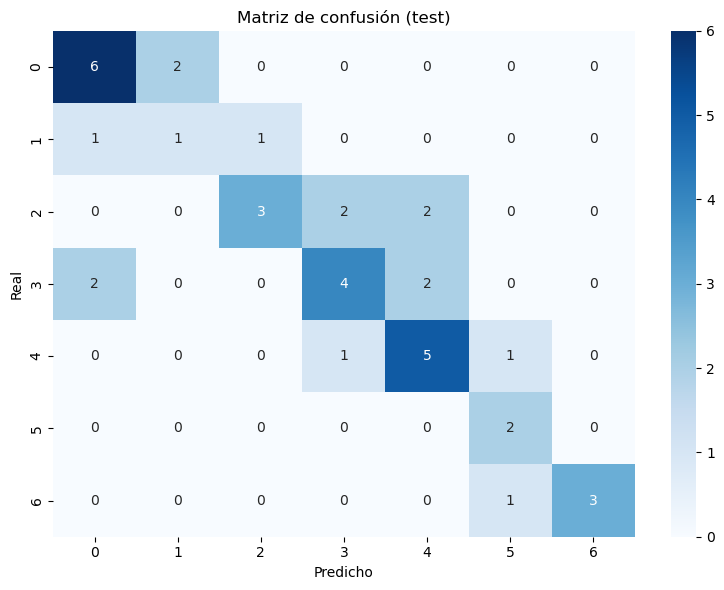

In [ ]:
# Correlación de Spearman
rho_train, p_train = stats.spearmanr(y_train, y_pred_train)
rho_test, p_test   = stats.spearmanr(y_test, y_pred_test)

print(f"Spearman Train: rho={rho_train:.3f} (p={p_train:.3f})")
print(f"Spearman Test:  rho={rho_test:.3f} (p={p_test:.3f})")

# Error Absoluto Medio (MAE)
from sklearn.metrics import mean_absolute_error
print(f"MAE Train: {mean_absolute_error(y_train, y_pred_train):.3f} puntos")
print(f"MAE Test:  {mean_absolute_error(y_test, y_pred_test):.3f} puntos")

# Accuracy dentro de +-1 punto mRS
within1_train = (abs(y_train - y_pred_train) <= 1).mean()
within1_test  = (abs(y_test  - y_pred_test)  <= 1).mean()
print(f"Accuracy +-1 punto Train: {within1_train:.3f}")
print(f"Accuracy +-1 punto Test:  {within1_test:.3f}")

# Matriz de confusión
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred_test)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=range(7), yticklabels=range(7))
plt.xlabel('Predicho')
plt.ylabel('Real')
plt.title('Matriz de confusión (test)')
plt.tight_layout()
plt.show()

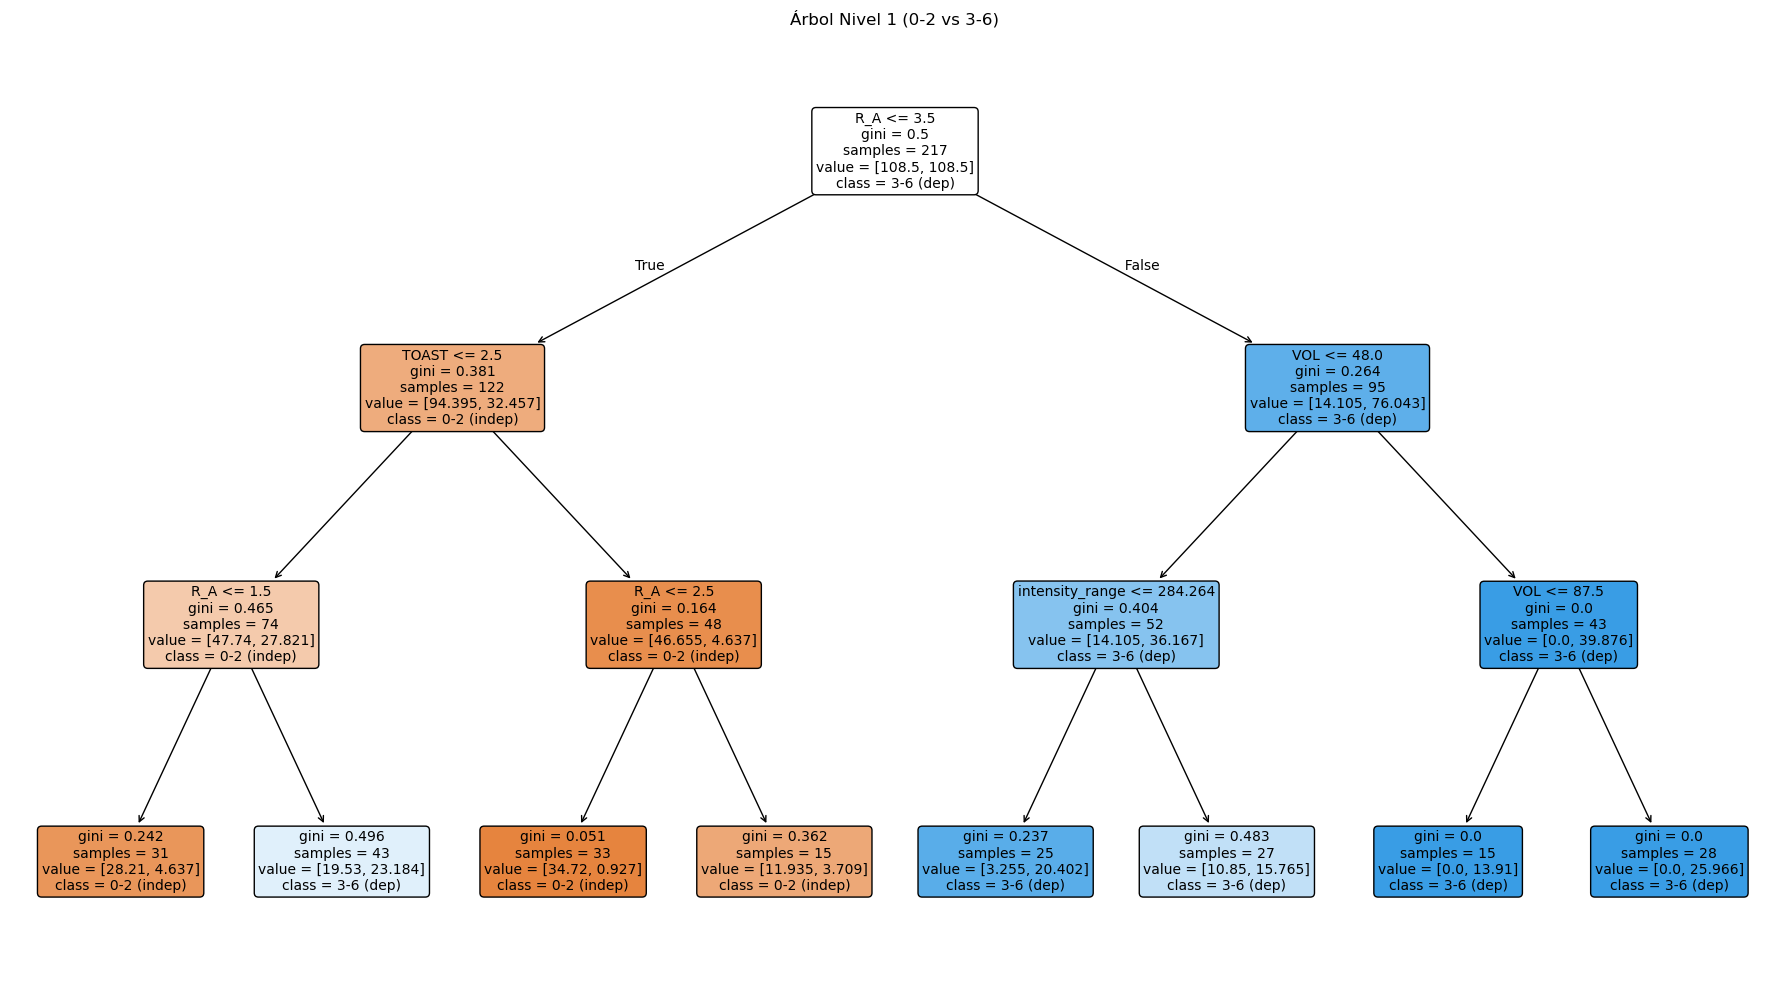

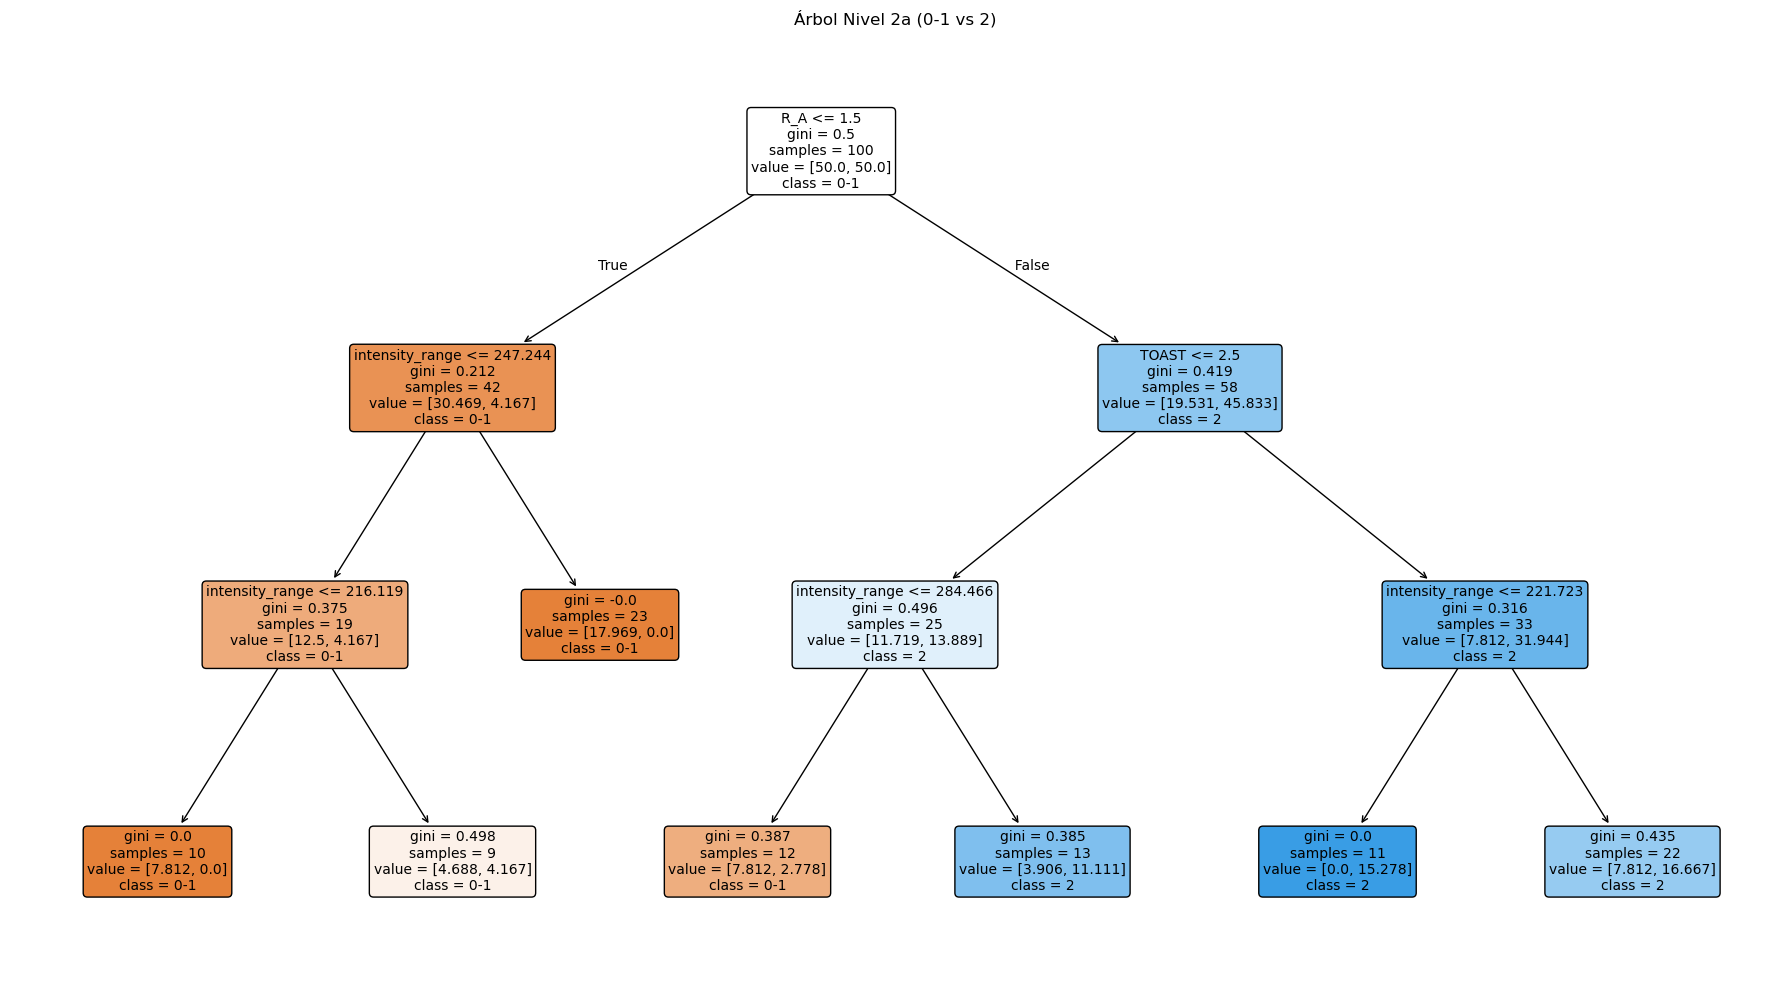

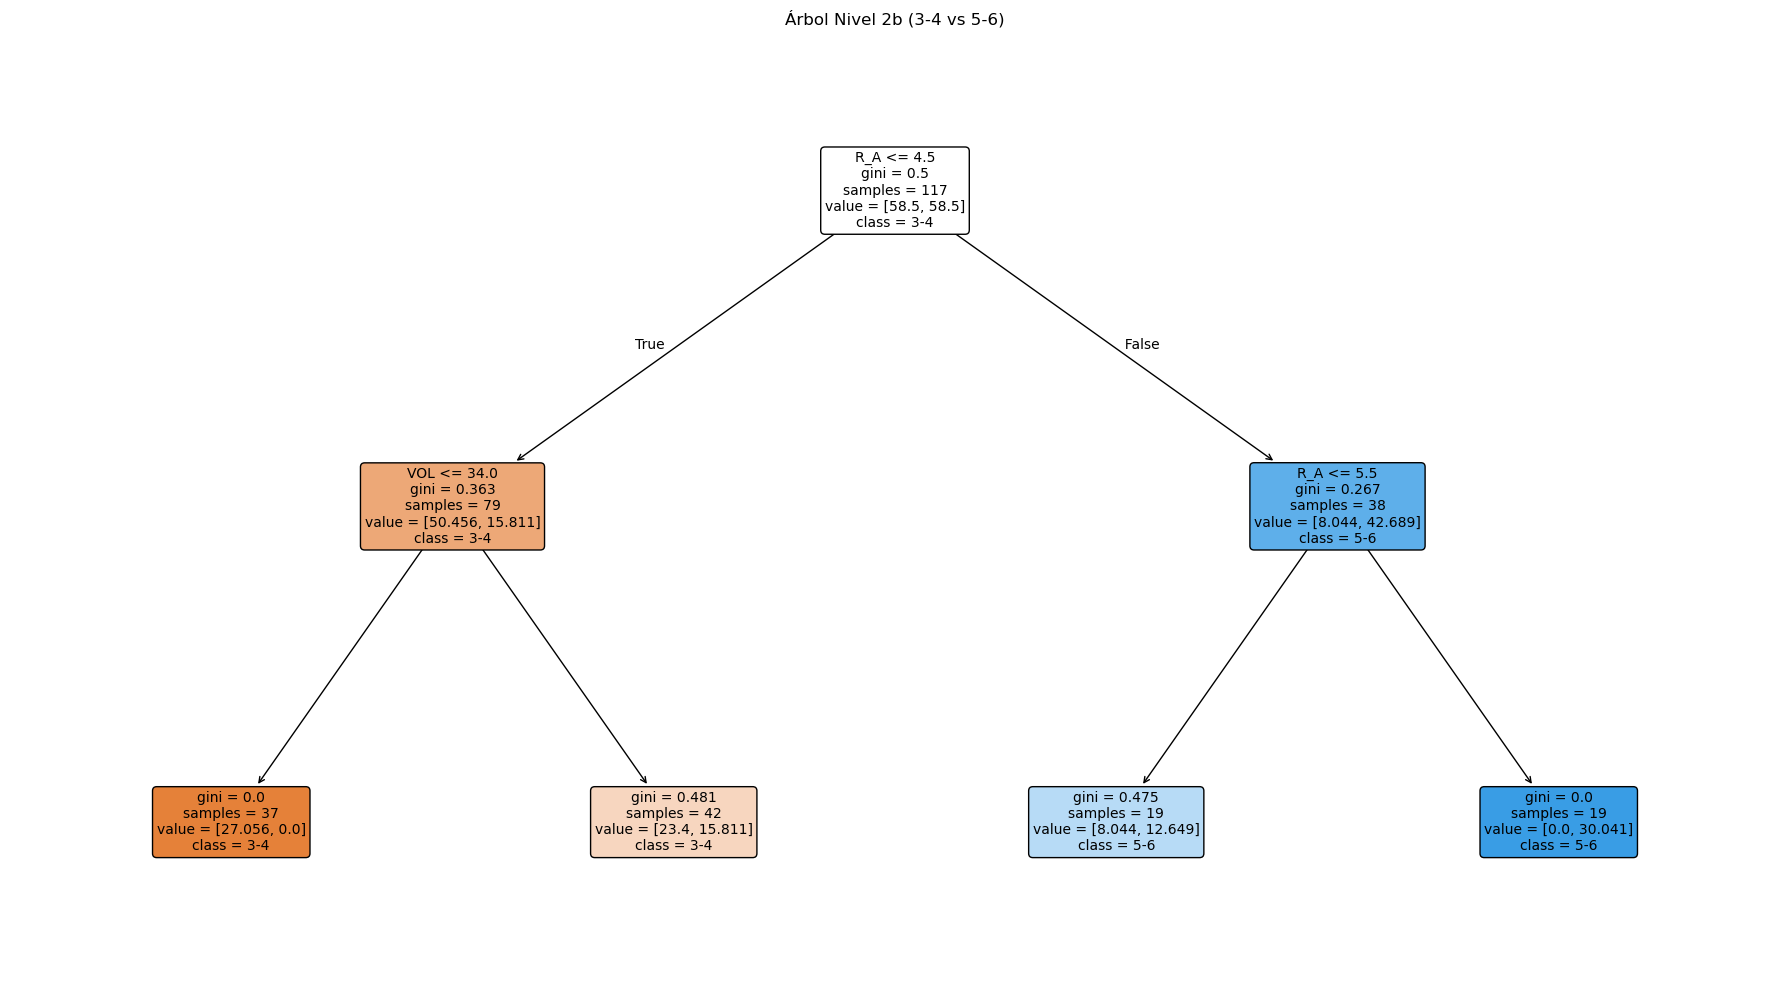

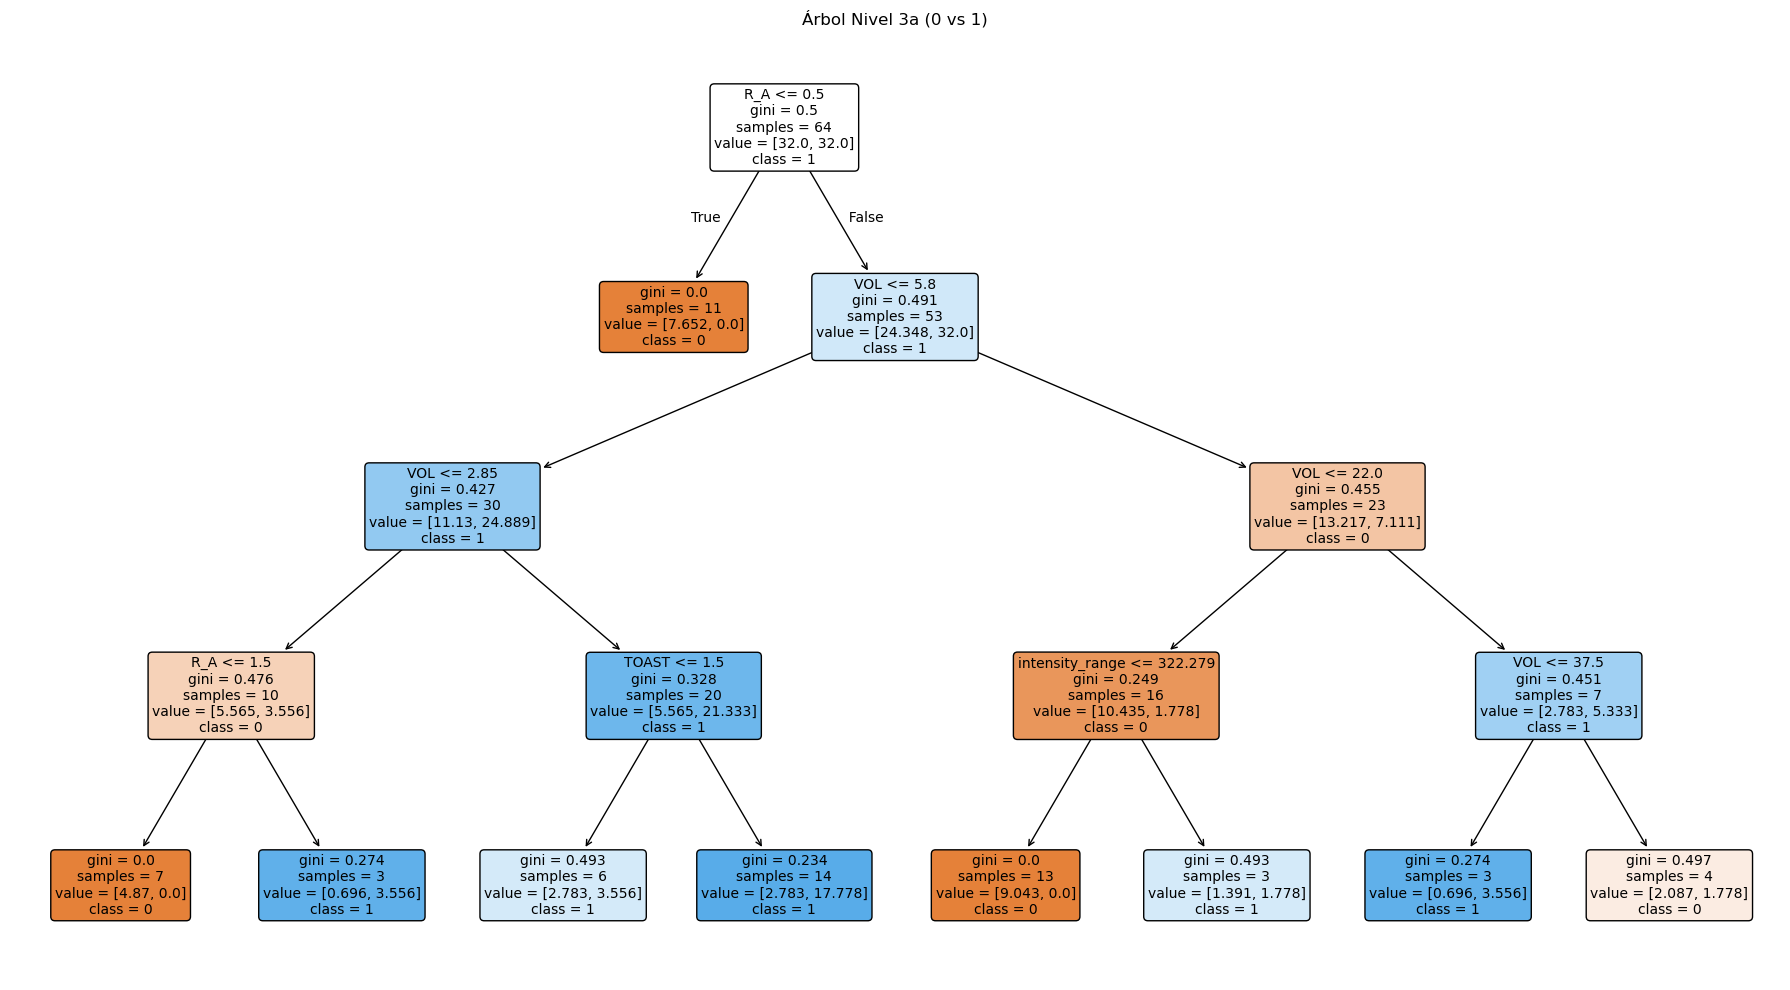

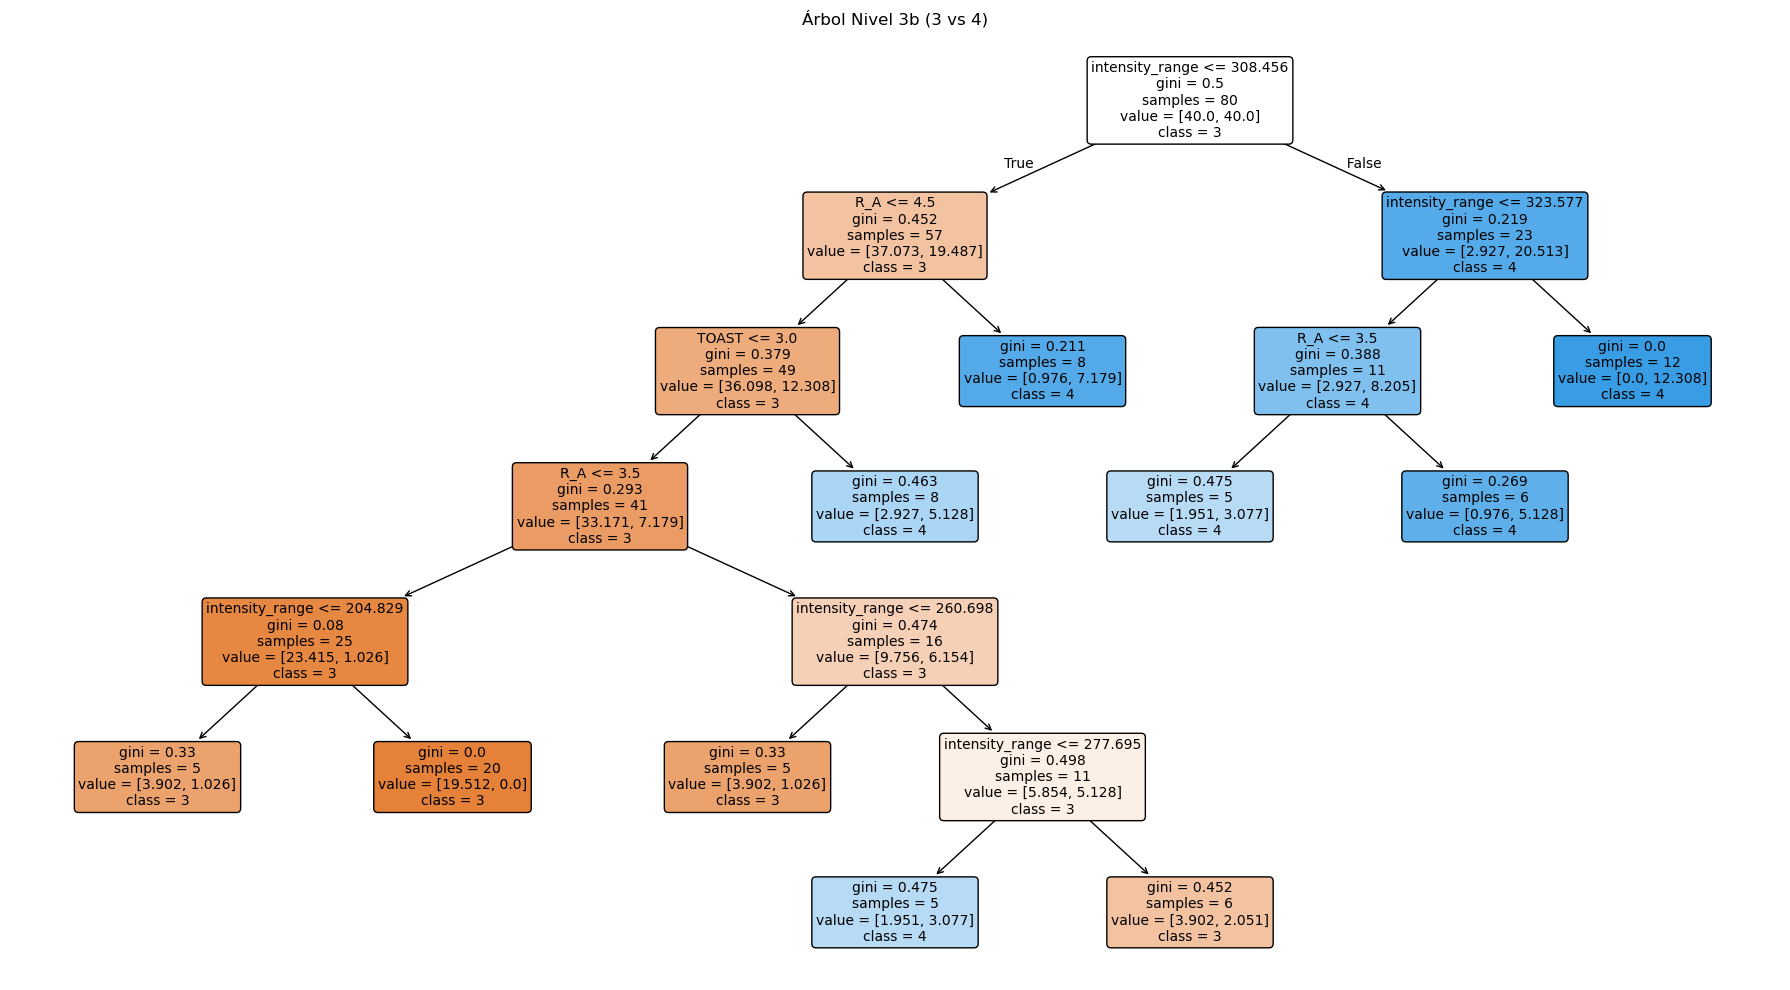

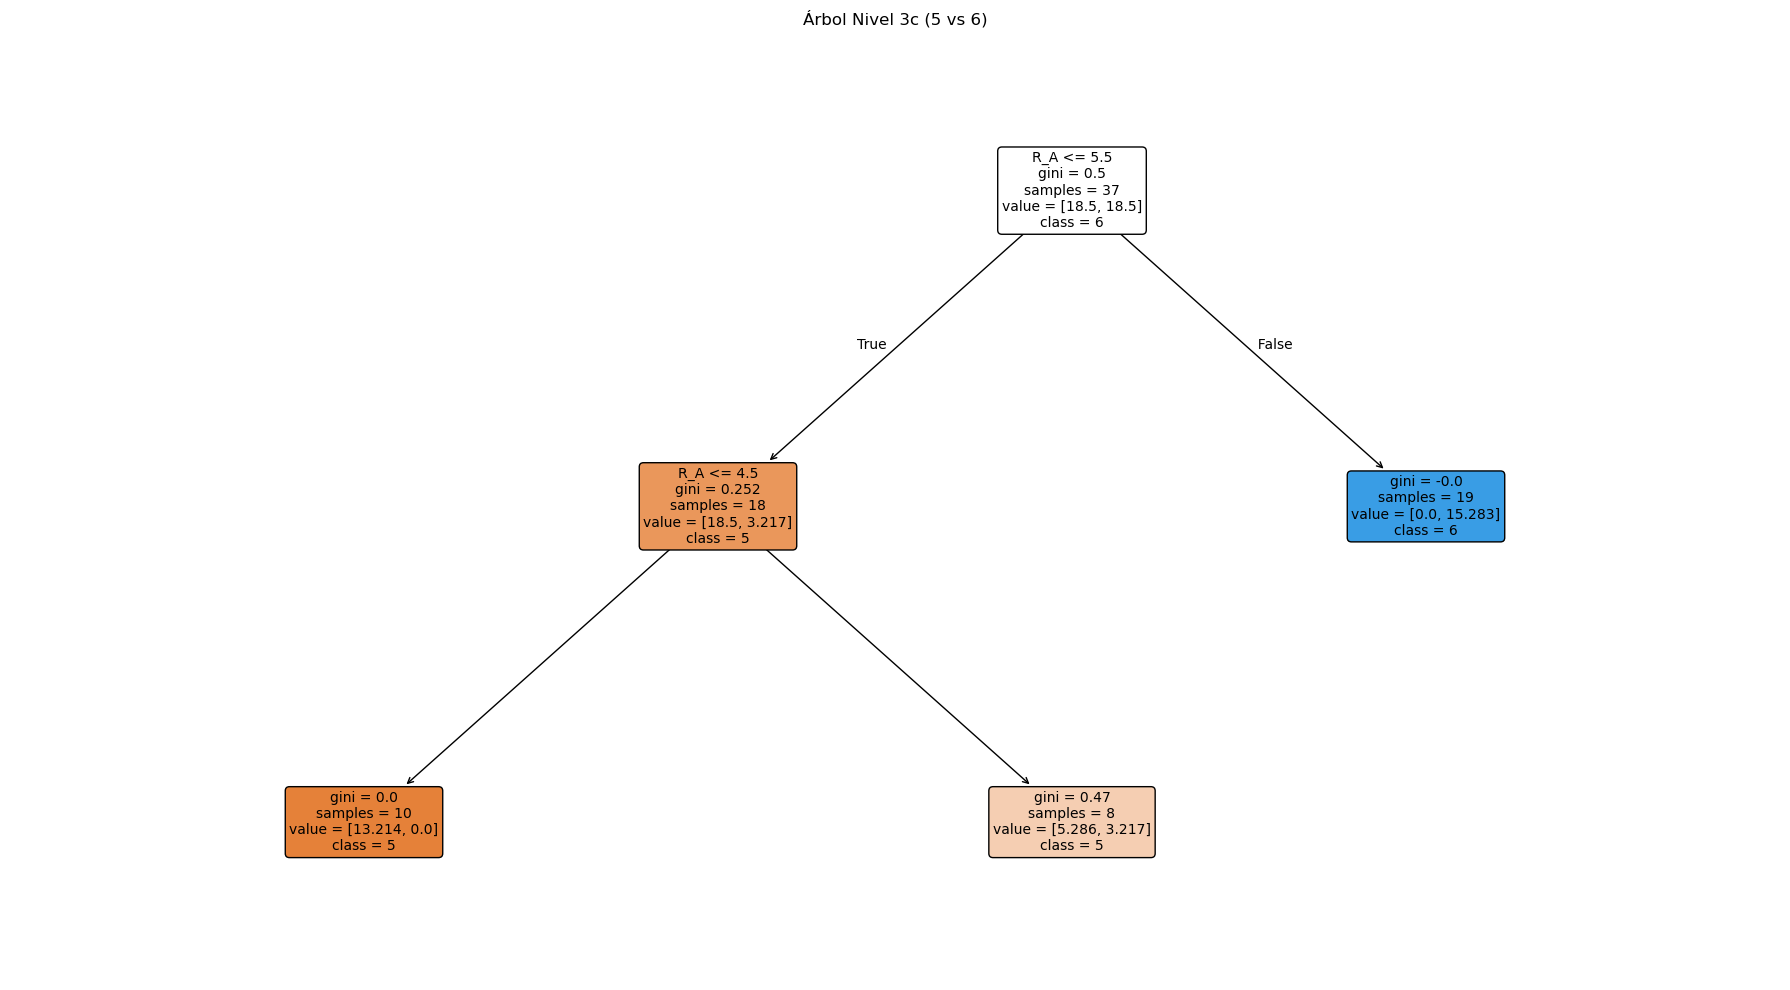

In [15]:
# Visualización de los árboles de decisión por nivel jerárquico
niveles_plot = {
    'Nivel 1 (0-2 vs 3-6)': (clf_jerarquico.gs_n1_, ['0-2 (indep)', '3-6 (dep)']),
    'Nivel 2a (0-1 vs 2)': (clf_jerarquico.gs_n2a_, ['0-1', '2']),
    'Nivel 2b (3-4 vs 5-6)': (clf_jerarquico.gs_n2b_, ['3-4', '5-6']),
    'Nivel 3a (0 vs 1)': (clf_jerarquico.gs_n3a_, ['0', '1']),
    'Nivel 3b (3 vs 4)': (clf_jerarquico.gs_n3b_, ['3', '4']),
    'Nivel 3c (5 vs 6)': (clf_jerarquico.gs_n3c_, ['5', '6']),
}

for titulo, (gs, class_names) in niveles_plot.items():
    arbol = gs.best_estimator_.named_steps['clf']
    plt.figure(figsize=(18, 10))
    plot_tree(
        arbol,
        feature_names=nombres_columnas,
        class_names=class_names,
        filled=True,
        rounded=True,
        fontsize=10
    )
    plt.title(f'Árbol {titulo}')
    plt.tight_layout()
    plt.show()